# 01 — Explore Data (Amazon Fine Food Reviews)

Objectif : charger `Reviews.csv`, valider le schéma, et faire une EDA approfondie (visualisations, distributions, wordclouds).

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Fix for Spark/Java compatibility
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"

spark = (
    SparkSession.builder
    .appName("AmazonFoodReviews-EDA")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

DATA_PATH = Path("../data/Reviews.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../Reviews.csv")

print("Using dataset:", DATA_PATH.resolve())

Using dataset: C:\Users\lenovo\Desktop\Data Engineering\mini-projest 2\data\Reviews.csv


In [2]:
# Load with robust options
df_raw = spark.read.csv(
    str(DATA_PATH),
    header=True,
    inferSchema=True,
    multiLine=True,
    escape='"'
)

# Keep useful columns
df = df_raw.select(
    F.col("Id").cast("long").alias("id"),
    F.col("Score").cast("int").alias("score"),
    F.col("Summary").cast("string").alias("summary"),
    F.col("Text").cast("string").alias("text"),
).filter(F.col("score").isNotNull()).cache()

print("Total valid records:", df.count())

Total valid records: 568454


## 1. Score Distribution

Visualisation de la répartition des notes (1 à 5 stars).

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11904\397321265.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="score", y="count", data=score_counts, palette="viridis")


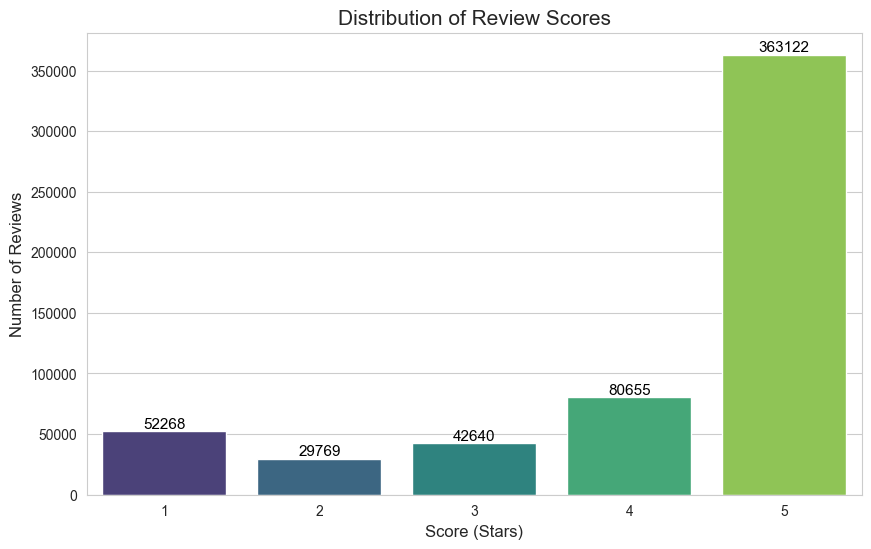

In [3]:
score_counts = df.groupBy("score").count().orderBy("score").toPandas()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x="score", y="count", data=score_counts, palette="viridis")
plt.title("Distribution of Review Scores", fontsize=15)
plt.xlabel("Score (Stars)", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

# Add labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

## 2. Review Length Analysis

Est-ce que les gens écrivent plus pour les notes négatives ?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11904\2421282632.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="score", y="text_len", data=sample_pd, palette="magma")


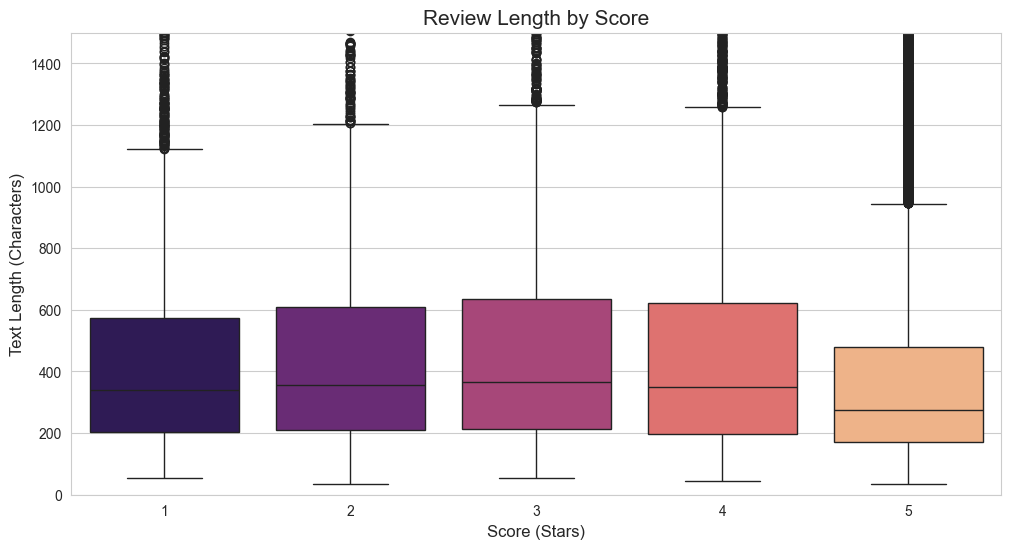

In [4]:
df_len = df.withColumn("text_len", F.length("text"))

# Sample data for visualization (to keep it fast)
sample_pd = df_len.select("score", "text_len").sample(0.1).toPandas()

plt.figure(figsize=(12, 6))
sns.boxplot(x="score", y="text_len", data=sample_pd, palette="magma")
plt.ylim(0, 1500) # Limit Y to see the bulk of the data
plt.title("Review Length by Score", fontsize=15)
plt.xlabel("Score (Stars)", fontsize=12)
plt.ylabel("Text Length (Characters)", fontsize=12)
plt.show()

## 3. Word Clouds

Mots les plus fréquents pour les avis Positifs (5) vs Négatifs (1).

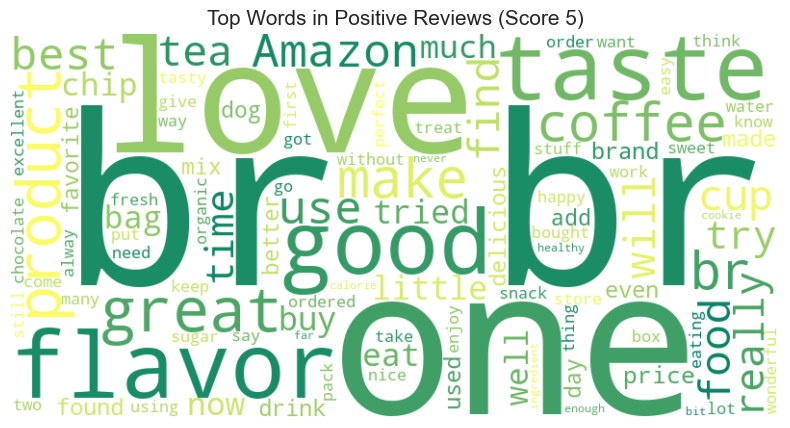

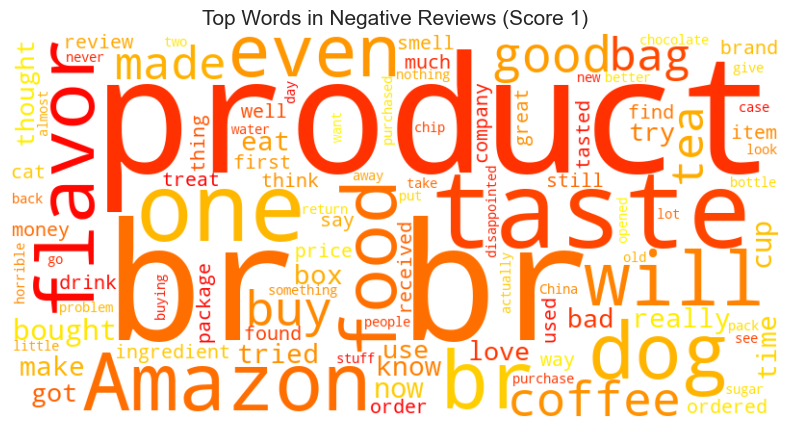

In [5]:
def plot_wordcloud(score, title, color):
    text_data = df.filter(F.col("score") == score).select("text").limit(5000).toPandas()
    all_text = " ".join(text_data['text'].tolist())
    
    wc = WordCloud(width=800, height=400, background_color='white', 
                   colormap=color, max_words=100).generate(all_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=15)
    plt.show()

plot_wordcloud(5, "Top Words in Positive Reviews (Score 5)", "summer")
plot_wordcloud(1, "Top Words in Negative Reviews (Score 1)", "autumn")